<a href="https://colab.research.google.com/github/Pavithra2006-15/Data_Science_Hackathon/blob/main/EdTech_Dropout_Single_Dataset_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
# Direct download from the Zenodo dataset
url = "https://zenodo.org/records/20383767/files/dataset_abandono.csv?download=1"

df = pd.read_csv(
    url,
    sep=";",
    decimal=","
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (290, 15)


,student_id,course,age,gender,socioeconomic_level,employed,semester,login_frequency,forum_participation,task_submissions,late_submissions,connection_time,resource_views,final_grade,dropout
0,613251039,ASS,45,F,2,SI,1,250,532,22,0,27.33,1499,4.7,NO
1,613251012,ASS,37,M,2,NO,4,371,402,36,0,24.13,1794,4.2,NO
2,613251003,ASS,18,F,1,SI,3,259,324,22,0,17.39,903,4.1,NO
3,613251036,ASS,23,F,1,NO,1,401,675,22,0,18.45,1808,4.4,NO
4,613251027,ASS,32,F,3,NO,4,242,273,20,0,12.13,835,4.3,NO


## 3. Inspect the actual dataset

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())


Rows: 290
Columns: 15

Column names:
['student_id', 'course', 'age', 'gender', 'socioeconomic_level', 'employed', 'semester', 'login_frequency', 'forum_participation', 'task_submissions', 'late_submissions', 'connection_time', 'resource_views', 'final_grade', 'dropout']

Data types:


,dtype
student_id,int64
course,object
age,int64
gender,object
socioeconomic_level,int64
employed,object
semester,int64
login_frequency,int64
forum_participation,int64
task_submissions,int64



Missing values:


,missing_count
student_id,0
course,0
age,0
gender,0
socioeconomic_level,0
employed,0
semester,0
login_frequency,0
forum_participation,0
task_submissions,0



Duplicate rows: 0


In [4]:
# Make a copy
df = df.copy()

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

numeric_cols = [
    "age",
    "socioeconomic_level",
    "semester",
    "login_frequency",
    "forum_participation",
    "task_submissions",
    "late_submissions",
    "connection_time",
    "resource_views",
    "final_grade"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean categorical columns
categorical_cols = [
    "course", "gender", "employed", "dropout"
]

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()

# Binary target
df["Dropout_Status"] = df["dropout"].map({
    "SI": 1,
    "NO": 0
})

# Remove rows where the target could not be interpreted
df = df.dropna(subset=["Dropout_Status"]).copy()
df["Dropout_Status"] = df["Dropout_Status"].astype(int)

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Basic validity checks
df["age"] = df["age"].clip(lower=0)
df["semester"] = df["semester"].clip(lower=0)
df["login_frequency"] = df["login_frequency"].clip(lower=0)
df["forum_participation"] = df["forum_participation"].clip(lower=0)
df["task_submissions"] = df["task_submissions"].clip(lower=0)
df["late_submissions"] = df["late_submissions"].clip(lower=0)
df["connection_time"] = df["connection_time"].clip(lower=0)
df["resource_views"] = df["resource_views"].clip(lower=0)

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (290, 16)


,student_id,course,age,gender,socioeconomic_level,employed,semester,login_frequency,forum_participation,task_submissions,late_submissions,connection_time,resource_views,final_grade,dropout,Dropout_Status
0,613251039,ASS,45,F,2,SI,1,250,532,22,0,27.33,1499,4.7,NO,0
1,613251012,ASS,37,M,2,NO,4,371,402,36,0,24.13,1794,4.2,NO,0
2,613251003,ASS,18,F,1,SI,3,259,324,22,0,17.39,903,4.1,NO,0
3,613251036,ASS,23,F,1,NO,1,401,675,22,0,18.45,1808,4.4,NO,0
4,613251027,ASS,32,F,3,NO,4,242,273,20,0,12.13,835,4.3,NO,0


## 5. Descriptive statistics

In [5]:
analysis_numeric = [
    "age",
    "login_frequency",
    "forum_participation",
    "task_submissions",
    "late_submissions",
    "connection_time",
    "resource_views",
    "final_grade"
]

display(df[analysis_numeric].describe().round(2))

print("\nDropout distribution:")
dropout_summary = (
    df["Dropout_Status"]
    .value_counts()
    .sort_index()
    .rename(index={0:"Did Not Drop Out", 1:"Dropped Out"})
    .to_frame("Students")
)

dropout_summary["Percentage"] = (
    dropout_summary["Students"] / len(df) * 100
).round(2)

display(dropout_summary)

print("\nCourse distribution:")
display(df["course"].value_counts().to_frame("Students"))


,age,login_frequency,forum_participation,task_submissions,late_submissions,connection_time,resource_views,final_grade
count,290.00,290.00,290.00,290.00,290.00,290.00,290.00,290.00
mean,32.70,234.66,322.68,20.26,0.22,26.95,1221.47,4.25
std,10.49,116.44,148.99,9.29,0.56,9.81,506.17,2.37
min,18.00,23.00,9.00,3.00,0.00,8.45,109.00,2.10
25%,24.00,158.50,235.00,12.00,0.00,18.16,856.50,3.82
50%,31.00,222.00,300.50,21.00,0.00,28.22,1338.00,4.30
75%,40.00,310.75,411.00,27.00,0.00,35.18,1600.50,4.60
max,60.00,533.00,675.00,40.00,3.00,46.30,2762.00,43.00



Dropout distribution:


,Students,Percentage
Dropout_Status,,
Did Not Drop Out,264,91.03
Dropped Out,26,8.97



Course distribution:


,Students
course,
TO,99
ASS,97
RF,94


In [6]:
engagement_features = [
    "login_frequency",
    "forum_participation",
    "task_submissions",
    "connection_time",
    "resource_views"
]

def minmax(series):
    lo = series.min()
    hi = series.max()
    if hi == lo:
        return pd.Series(0.0, index=series.index)
    return (series - lo) / (hi - lo)

df["Engagement_Score"] = (
    0.25 * minmax(df["login_frequency"]) +
    0.20 * minmax(df["forum_participation"]) +
    0.20 * minmax(df["task_submissions"]) +
    0.15 * minmax(df["connection_time"]) +
    0.20 * minmax(df["resource_views"])
)

df["Engagement_Band"] = pd.cut(
    df["Engagement_Score"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["Low Engagement", "Medium Engagement", "High Engagement"]
)

display(
    df[
        ["student_id", "course", "Engagement_Score", "Engagement_Band",
         "Dropout_Status"]
    ].head()
)


,student_id,course,Engagement_Score,Engagement_Band,Dropout_Status
0,613251039,ASS,0.550643,Medium Engagement,0
1,613251012,ASS,0.656151,Medium Engagement,0
2,613251003,ASS,0.408270,Medium Engagement,0
3,613251036,ASS,0.655708,Medium Engagement,0
4,613251027,ASS,0.347838,Medium Engagement,0


# 7. Visualisation 1 — Dropout distribution

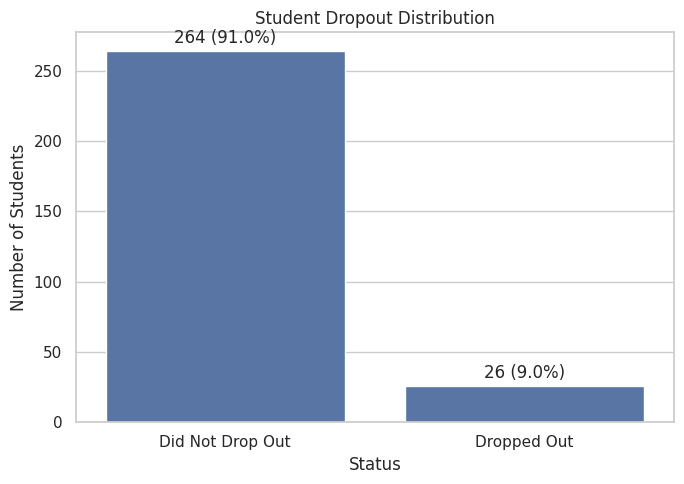

In [7]:
status_counts = (
    df["Dropout_Status"]
    .value_counts()
    .sort_index()
    .rename(index={0:"Did Not Drop Out", 1:"Dropped Out"})
)

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Student Dropout Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Students")

for i, value in enumerate(status_counts.values):
    pct = value / len(df) * 100
    ax.text(i, value + max(status_counts.values)*0.02,
            f"{value} ({pct:.1f}%)",
            ha="center")

plt.tight_layout()
plt.show()


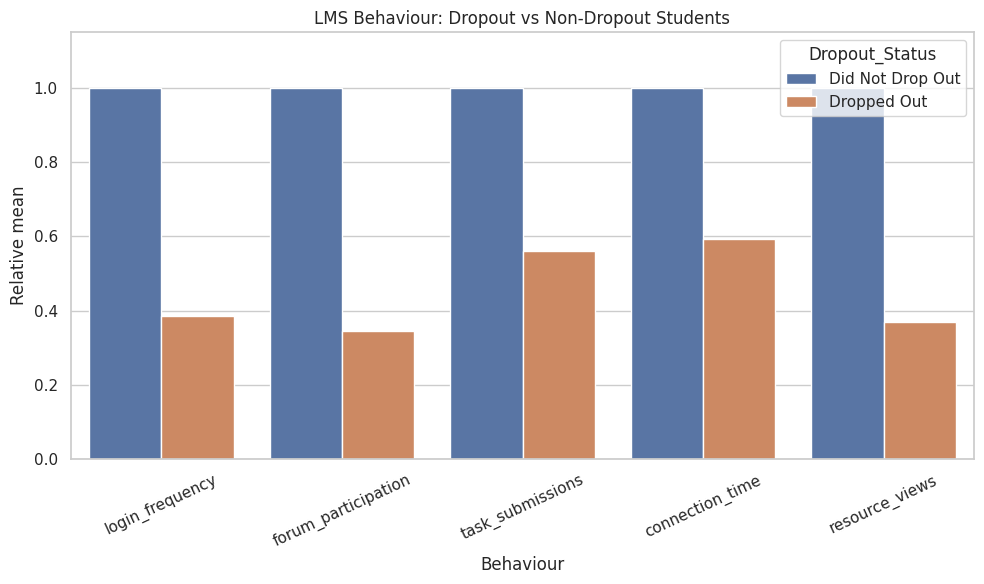

In [8]:
group_means = df.groupby("Dropout_Status")[engagement_features].mean().T
group_means.columns = ["Did Not Drop Out", "Dropped Out"]

plot_data = group_means.copy()

for index in plot_data.index:
    max_value = plot_data.loc[index].max()
    if max_value != 0:
        plot_data.loc[index] = plot_data.loc[index] / max_value

plot_data = plot_data.reset_index().rename(columns={"index":"Behaviour"})

long_data = plot_data.melt(
    id_vars="Behaviour",
    var_name="Dropout_Status",
    value_name="Relative_Mean"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=long_data,
    x="Behaviour",
    y="Relative_Mean",
    hue="Dropout_Status"
)

plt.title("LMS Behaviour: Dropout vs Non-Dropout Students")
plt.xlabel("Behaviour")
plt.ylabel("Relative mean")
plt.xticks(rotation=25)
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()


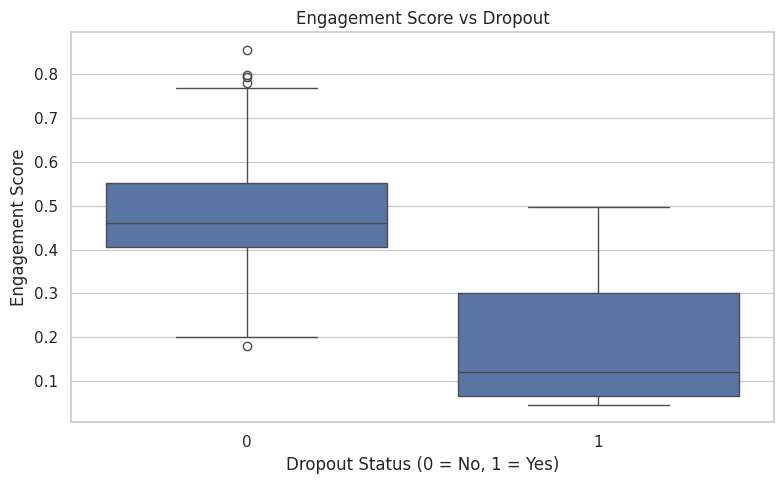

,count,mean,median,std
Dropout_Status,,,,
0,264,0.475,0.46,0.109
1,26,0.176,0.12,0.132


In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Dropout_Status",
    y="Engagement_Score"
)

plt.title("Engagement Score vs Dropout")
plt.xlabel("Dropout Status (0 = No, 1 = Yes)")
plt.ylabel("Engagement Score")

plt.tight_layout()
plt.show()

display(
    df.groupby("Dropout_Status")["Engagement_Score"]
      .agg(["count", "mean", "median", "std"])
      .round(3)
)


# 11. Identify the strongest behavioural differences

In [ ]:
behaviour_comparison = (
    df.groupby("Dropout_Status")[engagement_features]
      .mean()
      .T
)

behaviour_comparison.columns = ["Did Not Drop Out", "Dropped Out"]

behaviour_comparison["Difference"] = (
    behaviour_comparison["Dropped Out"] -
    behaviour_comparison["Did Not Drop Out"]
)

behaviour_comparison["Absolute_Difference"] = (
    behaviour_comparison["Difference"].abs()
)

behaviour_comparison = behaviour_comparison.sort_values(
    "Absolute_Difference",
    ascending=False
)

display(behaviour_comparison.round(3))

strongest_difference = behaviour_comparison.index[0]

print(
    f"Strongest observed behavioural separation: {strongest_difference}"
)


In [10]:
risk_stage = (
    df.groupby("Engagement_Band", observed=True)["Dropout_Status"]
      .agg(["count", "mean"])
      .reset_index()
      .rename(columns={"mean":"Dropout_Rate"})
)

risk_stage["Dropout_Rate"] *= 100

display(risk_stage.round(2))

highest_risk_band = risk_stage.loc[
    risk_stage["Dropout_Rate"].idxmax(),
    "Engagement_Band"
]

highest_risk_rate = risk_stage.loc[
    risk_stage["Dropout_Rate"].idxmax(),
    "Dropout_Rate"
]

print(
    f"Highest observed dropout rate occurs in the "
    f"{highest_risk_band} engagement band: {highest_risk_rate:.1f}%."
)


,Engagement_Band,count,Dropout_Rate
0,Low Engagement,42,50.00
1,Medium Engagement,237,2.11
2,High Engagement,11,0.00


Highest observed dropout rate occurs in the Low Engagement engagement band: 50.0%.


In [11]:
course_profile = (
    df.groupby("course")
      .agg(
          Students=("student_id", "count"),
          Dropout_Rate=("Dropout_Status", "mean"),
          Avg_Logins=("login_frequency", "mean"),
          Avg_Forum=("forum_participation", "mean"),
          Avg_Task_Submissions=("task_submissions", "mean"),
          Avg_Late_Submissions=("late_submissions", "mean"),
          Avg_Connection_Time=("connection_time", "mean"),
          Avg_Resource_Views=("resource_views", "mean"),
          Avg_Final_Grade=("final_grade", "mean")
      )
      .reset_index()
)

course_profile["Dropout_Rate"] *= 100

display(course_profile.round(2))


,course,Students,Dropout_Rate,Avg_Logins,Avg_Forum,Avg_Task_Submissions,Avg_Late_Submissions,Avg_Connection_Time,Avg_Resource_Views,Avg_Final_Grade
0,ASS,97,7.22,225.94,312.35,16.85,0.14,27.84,1352.92,4.68
1,RF,94,7.45,241.14,348.82,21.40,0.24,23.43,1215.33,4.08
2,TO,99,12.12,237.04,307.98,22.51,0.28,29.43,1098.52,3.99


In [12]:
df["Engagement_Quartile"] = pd.qcut(
    df["Engagement_Score"],
    q=4,
    labels=[
        "Q1 - Lowest Engagement",
        "Q2",
        "Q3",
        "Q4 - Highest Engagement"
    ],
    duplicates="drop"
)

quartile_analysis = (
    df.groupby("Engagement_Quartile", observed=True)["Dropout_Status"]
      .agg(["count", "mean"])
      .reset_index()
)

quartile_analysis["Dropout_Rate"] = quartile_analysis["mean"] * 100
quartile_analysis = quartile_analysis.drop(columns="mean")

display(quartile_analysis.round(2))

engagement_dropout_corr = df[
    ["Engagement_Score", "Dropout_Status"]
].corr().iloc[0,1]

print(
    f"Correlation between Engagement Score and Dropout Status: "
    f"{engagement_dropout_corr:.3f}"
)


,Engagement_Quartile,count,Dropout_Rate
0,Q1 - Lowest Engagement,73,34.25
1,Q2,74,0.00
2,Q3,70,1.43
3,Q4 - Highest Engagement,73,0.00


Correlation between Engagement Score and Dropout Status: -0.612


# 16. Train Random Forest

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Random Forest training completed.")


Random Forest training completed.


# 17. Model evaluation

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(metrics_df.round(4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Did Not Drop Out", "Dropped Out"],
        zero_division=0
    )
)


,Metric,Score
0,Accuracy,0.9310
1,Precision,0.6667
2,Recall,0.4000
3,F1 Score,0.5000
4,ROC-AUC,0.9774



Classification Report:
                  precision    recall  f1-score   support

Did Not Drop Out       0.95      0.98      0.96        53
     Dropped Out       0.67      0.40      0.50         5

        accuracy                           0.93        58
       macro avg       0.81      0.69      0.73        58
    weighted avg       0.92      0.93      0.92        58



# 18. Confusion matrix

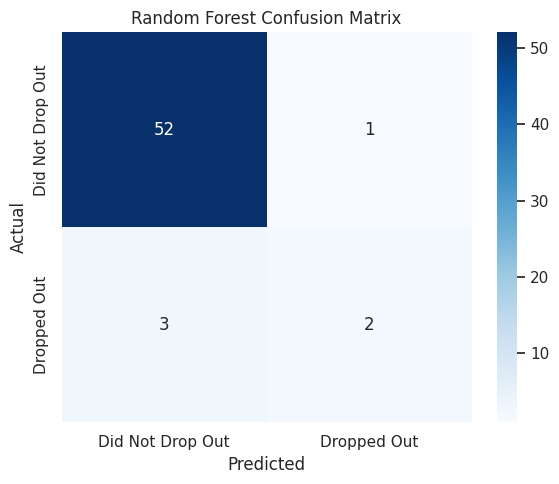

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Drop Out", "Dropped Out"],
    yticklabels=["Did Not Drop Out", "Dropped Out"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# 19. ROC curve

In [17]:
risk_df = df[
    [
        "student_id",
        "course",
        "login_frequency",
        "forum_participation",
        "task_submissions",
        "late_submissions",
        "connection_time",
        "resource_views",
        "Engagement_Score",
        "Dropout_Status"
    ]
].copy()

risk_df["Predicted_Dropout_Probability"] = model.predict_proba(
    df[features]
)[:, 1]

risk_df["Risk_Level"] = pd.cut(
    risk_df["Predicted_Dropout_Probability"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Risk distribution:")
display(
    risk_df["Risk_Level"]
    .value_counts()
    .to_frame("Students")
)

print("\nHighest-risk learners:")
display(
    risk_df.sort_values(
        "Predicted_Dropout_Probability",
        ascending=False
    ).head(15)
)


Risk distribution:


,Students
Risk_Level,
Low Risk,264
High Risk,21
Medium Risk,5



Highest-risk learners:


,student_id,course,login_frequency,forum_participation,task_submissions,late_submissions,connection_time,resource_views,Engagement_Score,Dropout_Status,Predicted_Dropout_Probability,Risk_Level
193,532999103,TO,23,13,6,1,11.23,345,0.046226,1,0.989193,High Risk
80,613252039,ASS,33,25,4,1,12.21,551,0.063334,1,0.985324,High Risk
165,330242026,RF,57,22,8,1,13.25,184,0.072274,1,0.984596,High Risk
261,533558302,TO,35,35,6,1,12.05,202,0.051184,1,0.980941,High Risk
219,533438245,TO,55,28,8,1,12.03,109,0.062607,1,0.980255,High Risk
13,613251016,ASS,45,50,9,2,12.02,749,0.117924,1,0.977077,High Risk
246,532848853,TO,45,17,9,1,12.34,171,0.065709,1,0.970971,High Risk
33,613251042,ASS,31,35,8,2,10.54,684,0.090386,1,0.969190,High Risk
134,330242039,RF,48,35,7,3,17.01,254,0.086539,1,0.964330,High Risk
76,613252026,ASS,60,27,3,1,10.03,460,0.056265,1,0.957839,High Risk


In [19]:
dropout_rate = df["Dropout_Status"].mean() * 100

dropouts = df[df["Dropout_Status"] == 1]
non_dropouts = df[df["Dropout_Status"] == 0]

print("KEY INSIGHTS")
print("=" * 70)

print(
    f"1. Overall dropout rate: {dropout_rate:.1f}% "
    f"({len(dropouts)} of {len(df)} students)."
)

for col in engagement_features:
    dropout_mean = dropouts[col].mean()
    non_dropout_mean = non_dropouts[col].mean()

    print(
        f"2. {col}: dropout students average "
        f"{dropout_mean:.2f}, compared with "
        f"{non_dropout_mean:.2f} among non-dropout students."
    )

print(
    f"3. The largest behavioural separation is observed for "
    f"{strongest_difference}."
)

print(
    f"4. Engagement score/dropout correlation is "
    f"{engagement_dropout_corr:.3f}."
)

print(
    f"5. The highest-risk engagement band is "
    f"{highest_risk_band}, with a dropout rate of "
    f"{highest_risk_rate:.1f}%."
)

highest_course = course_dropout.iloc[0]
lowest_course = course_dropout.iloc[-1]

print(
    f"6. Course comparison: {highest_course['course']} has the highest "
    f"observed dropout rate ({highest_course['Dropout_Rate']:.1f}%), "
    f"while {lowest_course['course']} has the lowest "
    f"({lowest_course['Dropout_Rate']:.1f}%)."
)

print(
    f"7. The Random Forest ROC-AUC is {roc_auc:.3f}; "
    f"this measures discrimination on the held-out test set."
)


KEY INSIGHTS
1. Overall dropout rate: 9.0% (26 of 290 students).
2. login_frequency: dropout students average 95.69, compared with 248.34 among non-dropout students.
2. forum_participation: dropout students average 118.08, compared with 342.83 among non-dropout students.
2. task_submissions: dropout students average 11.81, compared with 21.09 among non-dropout students.
2. connection_time: dropout students average 16.60, compared with 27.97 among non-dropout students.
2. resource_views: dropout students average 478.46, compared with 1294.65 among non-dropout students.


NameError: name 'strongest_difference' is not defined